# SHAP Model Interpretability — AQI Predictor

Explaining what drives each horizon's AQI predictions, using SHAP
(SHapley Additive exPlanations) on the currently registered best
model per horizon — loaded the same way the live dashboard does,
so this analysis always reflects the actual deployed model.

In [1]:
# Setup and connect

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import hopsworks
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from dotenv import load_dotenv

load_dotenv()
plt.rcParams["figure.figsize"] = (10, 6)

project = hopsworks.login(
    host=os.getenv("HOPSWORKS_HOST"),
    project=os.getenv("HOPSWORKS_PROJECT"),
    api_key_value=os.getenv("HOPSWORKS_API_KEY"),
    engine="python",
)
fs = project.get_feature_store()
mr = project.get_model_registry()

BASE_FEATURES = [
    "us_aqi", "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide",
    "sulphur_dioxide", "ozone", "temperature_2m", "relative_humidity_2m",
    "wind_speed_10m", "wind_direction_10m", "surface_pressure",
    "precipitation", "shortwave_radiation", "day_of_week", "month",
    "day_of_year", "aqi_change_rate", "aqi_roll3", "aqi_roll7", "pm25_roll3",
]
WEATHER_VARS = [
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m",
    "wind_direction_10m", "surface_pressure", "precipitation",
    "shortwave_radiation",
]
HORIZON_NAMES = {1: "day1", 2: "day2", 3: "day3"}

2026-08-23 14:58:35,542 INFO: Initializing external client
2026-08-23 14:58:35,542 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-23 14:58:43,253 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41159


In [2]:
# Load data + replicate the exact train/test split

daily_fg = fs.get_feature_group(name="aqi_daily_features", version=2)
df = daily_fg.read()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"Loaded {len(df)} rows from aqi_daily_features (v2)")


def chronological_split(df: pd.DataFrame, test_fraction: float = 0.2):
    split_idx = int(len(df) * (1 - test_fraction))
    return df.iloc[:split_idx], df.iloc[split_idx:]


train_df, test_df = chronological_split(df)
print(f"Train: {train_df['date'].min().date()} to {train_df['date'].max().date()} ({len(train_df)} rows)")
print(f"Test:  {test_df['date'].min().date()} to {test_df['date'].max().date()} ({len(test_df)} rows)")

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.18s) 
Loaded 736 rows from aqi_daily_features (v2)
Train: 2024-08-15 to 2026-03-25 (588 rows)
Test:  2026-03-26 to 2026-08-20 (148 rows)


In [3]:
# Reusable helpers

def load_best_model(horizon_name: str):
    """Loads the LATEST registered version, matching app.py's fix —
    NOT get_best_model(), which scans all-time RMSE across every
    version ever registered and can surface a stale model from before
    the candidate pool changed."""
    all_versions = mr.get_models(name=f"aqi_predictor_{horizon_name}")
    latest = max(all_versions, key=lambda m: m.version)
    model_dir = latest.download()
    import joblib
    model = joblib.load(os.path.join(model_dir, "model.pkl"))
    return model, latest


def build_feature_sets(horizon: int):
    target_col = f"target_day{horizon}"
    weather_cols = [f"{var}_h{horizon}" for var in WEATHER_VARS]
    feature_cols = BASE_FEATURES + weather_cols
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    return X_train, y_train, X_test, y_test, feature_cols


def get_explainer(model, X_train: pd.DataFrame):
    if isinstance(model, (Ridge, ElasticNet)):
        background = shap.maskers.Independent(X_train, max_samples=100)
        return shap.LinearExplainer(model, background), "LinearExplainer"
    elif hasattr(model, "feature_importances_") or isinstance(model, RandomForestRegressor):
        return shap.TreeExplainer(model), "TreeExplainer"
    else:
        background = shap.sample(X_train, min(100, len(X_train)))
        return shap.Explainer(model.predict, background), "Generic Explainer"


def evaluate(model, X, y):
    preds = model.predict(X)
    return {
        "rmse": np.sqrt(mean_squared_error(y, preds)),
        "mae": mean_absolute_error(y, preds),
        "r2": r2_score(y, preds),
    }

In [4]:
# Stores each horizon's SHAP results for the cross-horizon comparison later
shap_results = {}

## Day 1 Forecast — Model Interpretability

In [5]:
# Day 1: load, evaluate, compute SHAP

HORIZON = 1
horizon_name = HORIZON_NAMES[HORIZON]

model, model_meta = load_best_model(horizon_name)
print(f"Loaded {horizon_name} model: {type(model).__name__} (Hopsworks version {model_meta.version})")

X_train, y_train, X_test, y_test, feature_cols = build_feature_sets(HORIZON)

metrics = evaluate(model, X_test, y_test)
print(f"\nHeld-out test metrics (same test set as train_models.py):")
print(f"  RMSE={metrics['rmse']:.2f}  MAE={metrics['mae']:.2f}  R2={metrics['r2']:.3f}")

explainer, explainer_name = get_explainer(model, X_train)
print(f"\nUsing {explainer_name} for {type(model).__name__}")

shap_values = explainer(X_test) if explainer_name != "LinearExplainer" else explainer.shap_values(X_test)

Downloading: 0.000%|          | 0/1497 elapsed<00:00 remaining<?

Loaded day1 model: Ridge (Hopsworks version 25) DONE

Held-out test metrics (same test set as train_models.py):
  RMSE=5.14  MAE=3.52  R2=0.821

Using LinearExplainer for Ridge


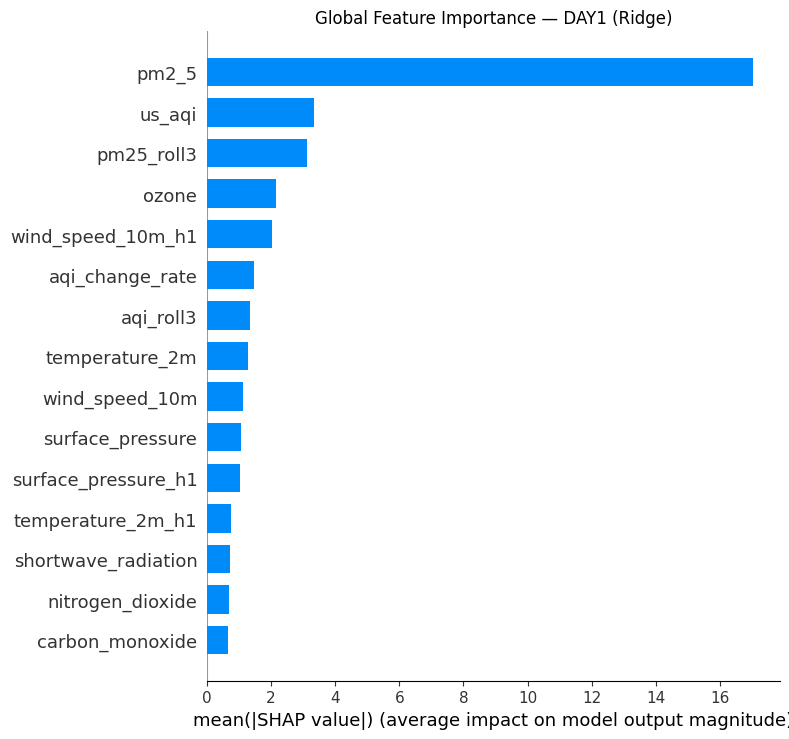

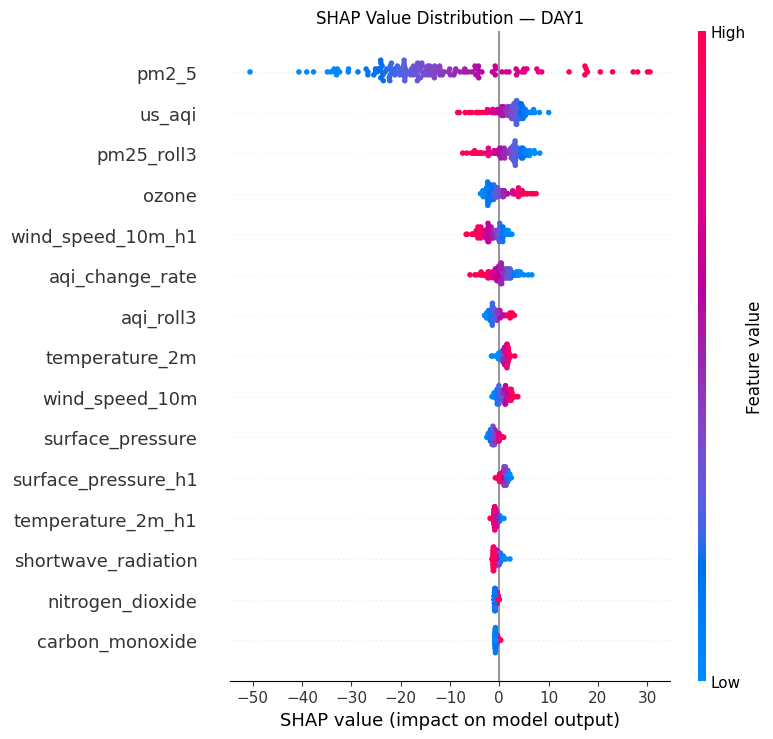

In [6]:
# Day 1: global importance (bar + beeswarm)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title(f"Global Feature Importance — {horizon_name.upper()} ({type(model).__name__})")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title(f"SHAP Value Distribution — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

Top feature for day1: pm2_5


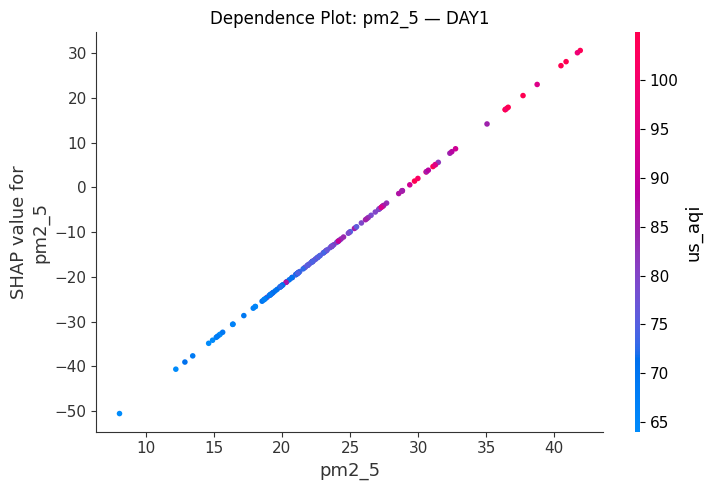

In [7]:
# Day 1: dependence plot on top feature

mean_abs_shap = np.abs(shap_values if isinstance(shap_values, np.ndarray) else shap_values.values).mean(axis=0)
top_feature = feature_cols[np.argmax(mean_abs_shap)]
print(f"Top feature for {horizon_name}: {top_feature}")

shap.dependence_plot(top_feature, shap_values if isinstance(shap_values, np.ndarray) else shap_values.values,
                      X_test, show=False)
plt.title(f"Dependence Plot: {top_feature} — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

shap_results[horizon_name] = {"feature_cols": feature_cols, "mean_abs_shap": mean_abs_shap}

Explaining day1 prediction for 2026-05-04
  Actual AQI: 122.5   Predicted: 124.9


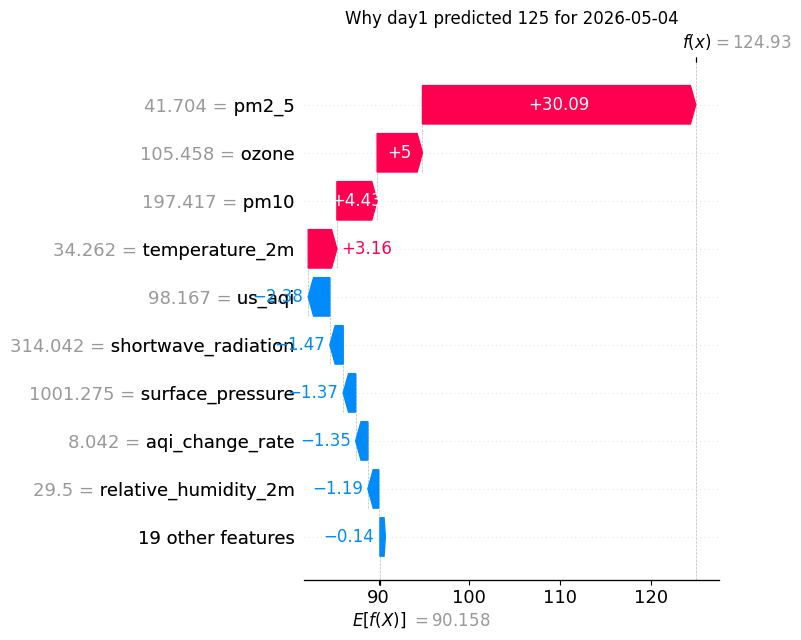

In [8]:
# Day 1: explain one specific, meaningful prediction
worst_idx_pos = y_test.values.argmax()
worst_date = test_df.iloc[worst_idx_pos]["date"].date()
actual_val = y_test.values[worst_idx_pos]
predicted_val = model.predict(X_test.iloc[[worst_idx_pos]])[0]

print(f"Explaining {horizon_name} prediction for {worst_date}")
print(f"  Actual AQI: {actual_val:.1f}   Predicted: {predicted_val:.1f}")

if explainer_name == "LinearExplainer":
    expected_value = explainer.expected_value
    row_shap = shap_values[worst_idx_pos]
else:
    expected_value = explainer.expected_value if hasattr(explainer, "expected_value") else shap_values.base_values[worst_idx_pos]
    row_shap = shap_values[worst_idx_pos].values if hasattr(shap_values[worst_idx_pos], "values") else shap_values[worst_idx_pos]

shap.plots.waterfall(
    shap.Explanation(
        values=row_shap,
        base_values=expected_value if np.isscalar(expected_value) else expected_value[0],
        data=X_test.iloc[worst_idx_pos].values,
        feature_names=feature_cols,
    ),
    show=False,
)
plt.title(f"Why {horizon_name} predicted {predicted_val:.0f} for {worst_date}")
plt.tight_layout()
plt.show()

## Day 2 Forecast — Model Interpretability

In [9]:
# Day 2: load, evaluate, compute SHAP

HORIZON = 2
horizon_name = HORIZON_NAMES[HORIZON]

model, model_meta = load_best_model(horizon_name)
print(f"Loaded {horizon_name} model: {type(model).__name__} (Hopsworks version {model_meta.version})")

X_train, y_train, X_test, y_test, feature_cols = build_feature_sets(HORIZON)

metrics = evaluate(model, X_test, y_test)
print(f"\nHeld-out test metrics (same test set as train_models.py):")
print(f"  RMSE={metrics['rmse']:.2f}  MAE={metrics['mae']:.2f}  R2={metrics['r2']:.3f}")

explainer, explainer_name = get_explainer(model, X_train)
print(f"\nUsing {explainer_name} for {type(model).__name__}")

shap_values = explainer(X_test) if explainer_name != "LinearExplainer" else explainer.shap_values(X_test)

Downloading: 0.000%|          | 0/1497 elapsed<00:00 remaining<?

Loaded day2 model: Ridge (Hopsworks version 24) DONE

Held-out test metrics (same test set as train_models.py):
  RMSE=9.31  MAE=7.10  R2=0.414

Using LinearExplainer for Ridge


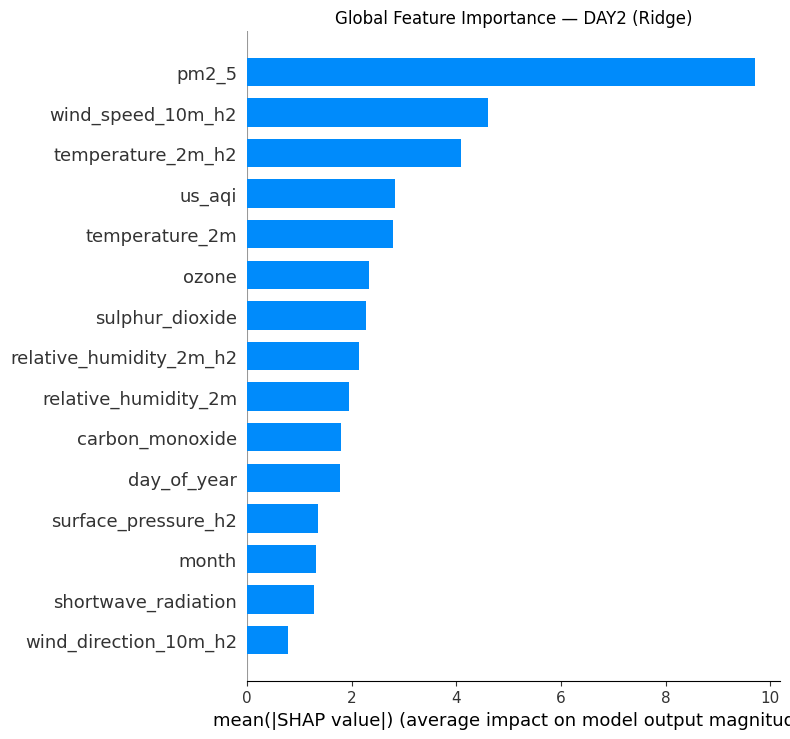

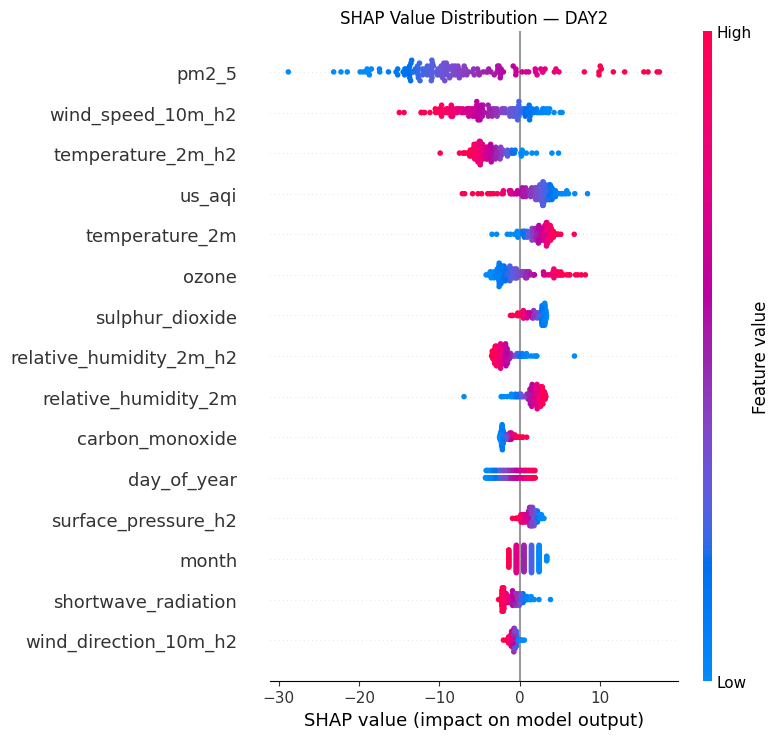

In [10]:
# Day 2: global importance (bar + beeswarm)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title(f"Global Feature Importance — {horizon_name.upper()} ({type(model).__name__})")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title(f"SHAP Value Distribution — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

Top feature for day2: pm2_5


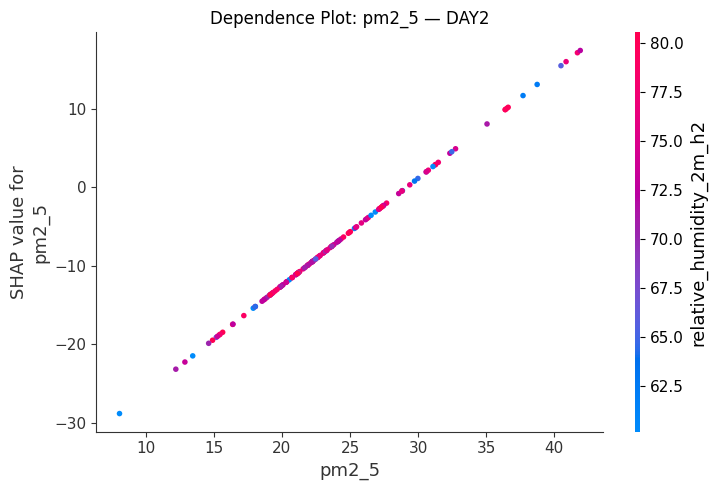

In [11]:
# Day 2: dependence plot on top feature

mean_abs_shap = np.abs(shap_values if isinstance(shap_values, np.ndarray) else shap_values.values).mean(axis=0)
top_feature = feature_cols[np.argmax(mean_abs_shap)]
print(f"Top feature for {horizon_name}: {top_feature}")

shap.dependence_plot(top_feature, shap_values if isinstance(shap_values, np.ndarray) else shap_values.values,
                      X_test, show=False)
plt.title(f"Dependence Plot: {top_feature} — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

shap_results[horizon_name] = {"feature_cols": feature_cols, "mean_abs_shap": mean_abs_shap}

Explaining day2 prediction for 2026-05-03
  Actual AQI: 122.5   Predicted: 88.9


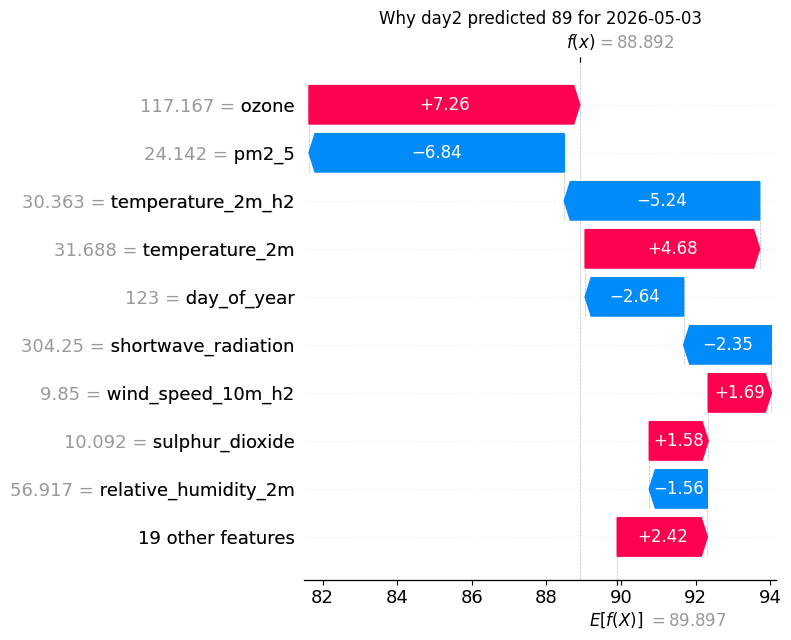

In [12]:
# Day 2: explain the worst test-set day

worst_idx_pos = y_test.values.argmax()
worst_date = test_df.iloc[worst_idx_pos]["date"].date()
actual_val = y_test.values[worst_idx_pos]
predicted_val = model.predict(X_test.iloc[[worst_idx_pos]])[0]

print(f"Explaining {horizon_name} prediction for {worst_date}")
print(f"  Actual AQI: {actual_val:.1f}   Predicted: {predicted_val:.1f}")

if explainer_name == "LinearExplainer":
    expected_value = explainer.expected_value
    row_shap = shap_values[worst_idx_pos]
else:
    expected_value = explainer.expected_value if hasattr(explainer, "expected_value") else shap_values.base_values[worst_idx_pos]
    row_shap = shap_values[worst_idx_pos].values if hasattr(shap_values[worst_idx_pos], "values") else shap_values[worst_idx_pos]

shap.plots.waterfall(
    shap.Explanation(
        values=row_shap,
        base_values=expected_value if np.isscalar(expected_value) else expected_value[0],
        data=X_test.iloc[worst_idx_pos].values,
        feature_names=feature_cols,
    ),
    show=False,
)
plt.title(f"Why {horizon_name} predicted {predicted_val:.0f} for {worst_date}")
plt.tight_layout()
plt.show()

## Day 3 Forecast — Model Interpretability

In [13]:
# Day 3: load, evaluate, compute SHAP

HORIZON = 3
horizon_name = HORIZON_NAMES[HORIZON]

model, model_meta = load_best_model(horizon_name)
print(f"Loaded {horizon_name} model: {type(model).__name__} (Hopsworks version {model_meta.version})")

X_train, y_train, X_test, y_test, feature_cols = build_feature_sets(HORIZON)

metrics = evaluate(model, X_test, y_test)
print(f"\nHeld-out test metrics (same test set as train_models.py):")
print(f"  RMSE={metrics['rmse']:.2f}  MAE={metrics['mae']:.2f}  R2={metrics['r2']:.3f}")

explainer, explainer_name = get_explainer(model, X_train)
print(f"\nUsing {explainer_name} for {type(model).__name__}")

shap_values = explainer(X_test) if explainer_name != "LinearExplainer" else explainer.shap_values(X_test)

Downloading: 0.000%|          | 0/1576 elapsed<00:00 remaining<?

Loaded day3 model: ElasticNet (Hopsworks version 23)

Held-out test metrics (same test set as train_models.py):
  RMSE=10.50  MAE=7.92  R2=0.223

Using LinearExplainer for ElasticNet


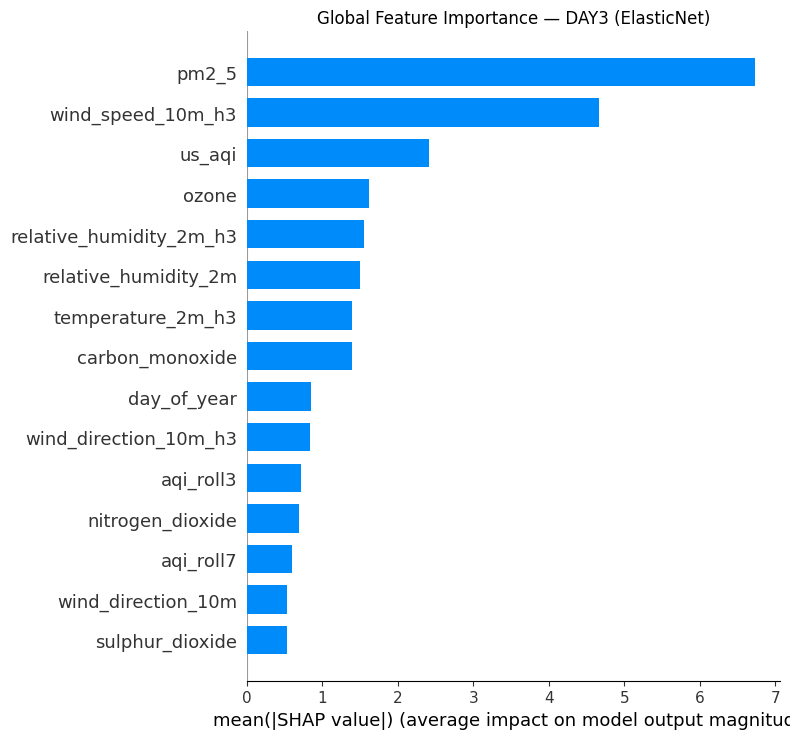

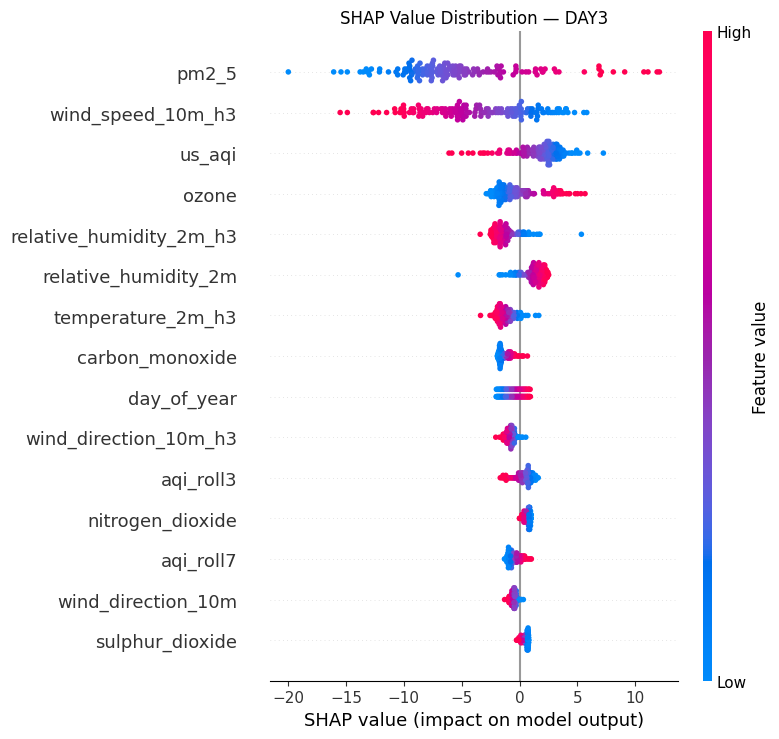

In [14]:
# Day 3: global importance (bar + beeswarm)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title(f"Global Feature Importance — {horizon_name.upper()} ({type(model).__name__})")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title(f"SHAP Value Distribution — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

Top feature for day3: pm2_5


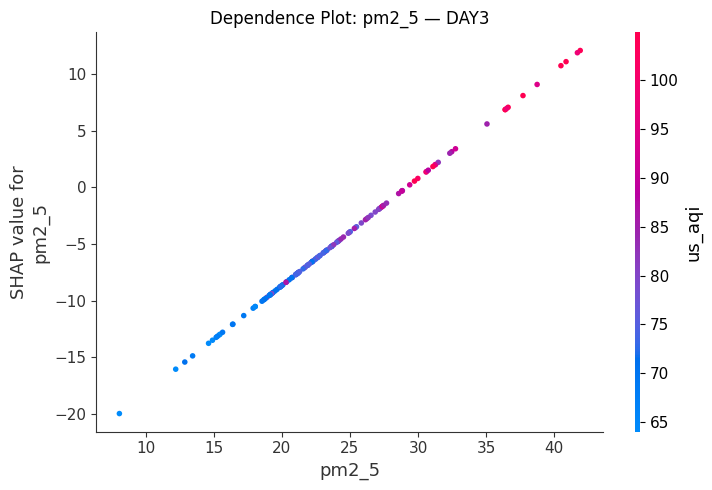

In [15]:
# Day 3: dependence plot on top feature

mean_abs_shap = np.abs(shap_values if isinstance(shap_values, np.ndarray) else shap_values.values).mean(axis=0)
top_feature = feature_cols[np.argmax(mean_abs_shap)]
print(f"Top feature for {horizon_name}: {top_feature}")

shap.dependence_plot(top_feature, shap_values if isinstance(shap_values, np.ndarray) else shap_values.values,
                      X_test, show=False)
plt.title(f"Dependence Plot: {top_feature} — {horizon_name.upper()}")
plt.tight_layout()
plt.show()

shap_results[horizon_name] = {"feature_cols": feature_cols, "mean_abs_shap": mean_abs_shap}

Explaining day3 prediction for 2026-05-02
  Actual AQI: 122.5   Predicted: 88.8


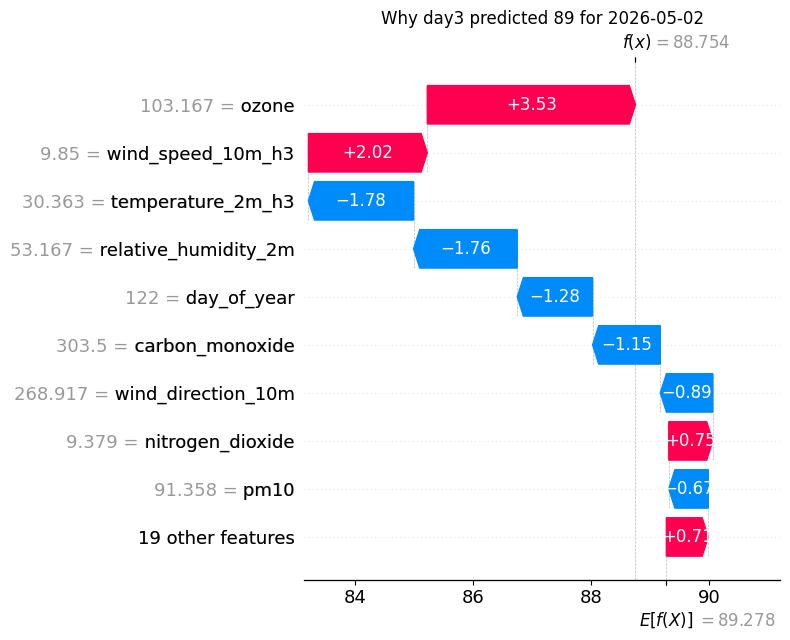

In [16]:
# Day 3: explain the worst test-set day

worst_idx_pos = y_test.values.argmax()
worst_date = test_df.iloc[worst_idx_pos]["date"].date()
actual_val = y_test.values[worst_idx_pos]
predicted_val = model.predict(X_test.iloc[[worst_idx_pos]])[0]

print(f"Explaining {horizon_name} prediction for {worst_date}")
print(f"  Actual AQI: {actual_val:.1f}   Predicted: {predicted_val:.1f}")

if explainer_name == "LinearExplainer":
    expected_value = explainer.expected_value
    row_shap = shap_values[worst_idx_pos]
else:
    expected_value = explainer.expected_value if hasattr(explainer, "expected_value") else shap_values.base_values[worst_idx_pos]
    row_shap = shap_values[worst_idx_pos].values if hasattr(shap_values[worst_idx_pos], "values") else shap_values[worst_idx_pos]

shap.plots.waterfall(
    shap.Explanation(
        values=row_shap,
        base_values=expected_value if np.isscalar(expected_value) else expected_value[0],
        data=X_test.iloc[worst_idx_pos].values,
        feature_names=feature_cols,
    ),
    show=False,
)
plt.title(f"Why {horizon_name} predicted {predicted_val:.0f} for {worst_date}")
plt.tight_layout()
plt.show()

## Cross-Horizon Comparison — How Feature Importance Shifts

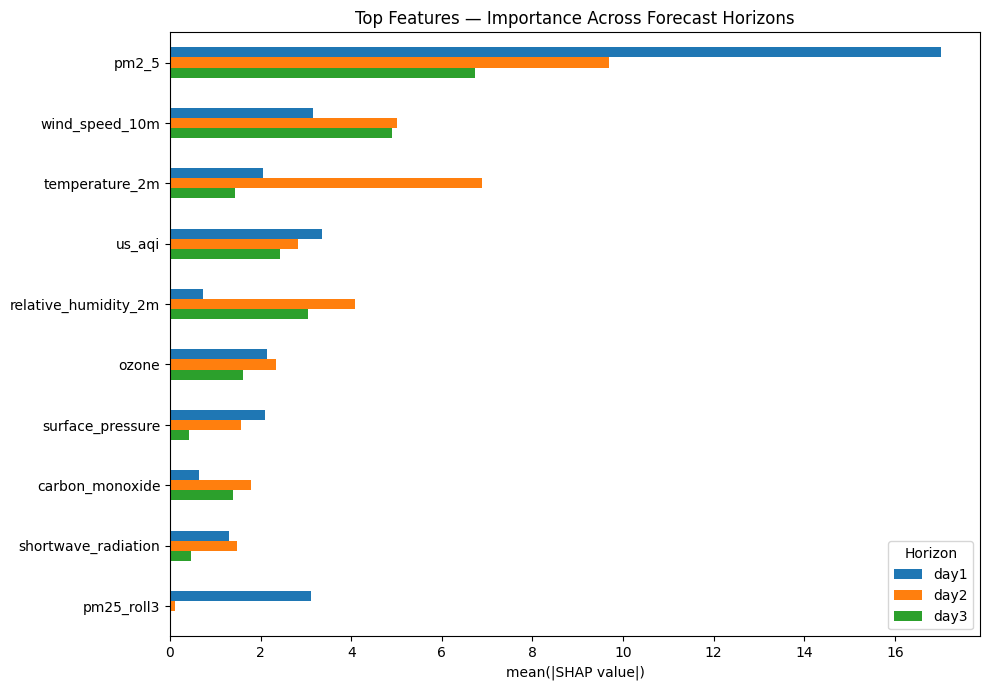

                           day1      day2      day3
pm2_5                 17.027972  9.696856  6.727369
wind_speed_10m         3.152058  5.004453  4.895929
temperature_2m         2.051216  6.885167  1.424787
us_aqi                 3.351697  2.828628  2.419740
relative_humidity_2m   0.735577  4.090264  3.049671
ozone                  2.141937  2.342632  1.617744
surface_pressure       2.100712  1.568913  0.412406
carbon_monoxide        0.642061  1.794834  1.387305
shortwave_radiation    1.313076  1.480701  0.474978
pm25_roll3             3.115026  0.116172  0.000000


In [17]:
def normalize_feature_name(f: str) -> str:
    """Strips the _h1/_h2/_h3 suffix so e.g. temperature_2m_h1 (day1's
    target-day weather) and temperature_2m_h3 (day3's) are treated as
    the same underlying concept for comparison across horizons."""
    for h in (1, 2, 3):
        suffix = f"_h{h}"
        if f.endswith(suffix):
            return f[: -len(suffix)]
    return f

# Build a wide table: rows = normalized feature name, columns = horizon
rows = {}
for horizon_name, result in shap_results.items():
    for feat, val in zip(result["feature_cols"], result["mean_abs_shap"]):
        norm = normalize_feature_name(feat)
        rows.setdefault(norm, {})[horizon_name] = rows.get(norm, {}).get(horizon_name, 0) + val

comparison_df = pd.DataFrame(rows).T.fillna(0)
comparison_df = comparison_df[["day1", "day2", "day3"]]
comparison_df["avg"] = comparison_df.mean(axis=1)
comparison_df = comparison_df.sort_values("avg", ascending=False).drop(columns="avg")

top_n = comparison_df.head(10)

top_n.plot(kind="barh", figsize=(10, 7))
plt.xlabel("mean(|SHAP value|)")
plt.title("Top Features — Importance Across Forecast Horizons")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.legend(title="Horizon")
plt.show()

print(top_n)

## Key Findings

**PM2.5 dominates but its influence decays with horizon.** It's the 
top feature at every horizon, but its mean impact drops from ~17 
(day1) to ~7 (day3) — today's pollution level strongly predicts 
tomorrow, but that direct persistence weakens the further out the 
forecast reaches, as expected for a physical process that isn't 
purely autoregressive.

**Weather features gain relative importance as PM2.5 fades**, 
particularly wind speed and relative humidity — both hold steady or 
grow in importance from day1 to day3. This independently confirms 
the dispersion mechanism found in the EDA (wind speed correlated 
-0.51 with AQI), arrived at through a completely different method 
(per-prediction attribution vs. correlation).

**Short-term rolling features (pm25_roll3) matter most for day1 and 
fade quickly** — consistent with them capturing a 3-day trailing 
trend, which naturally loses predictive power further into the future.

**Day2's higher reliance on temperature_2m should be read cautiously** 
— day2 has the lowest R² and stability of the three horizons, so this 
may partly reflect noise rather than a strong physical relationship.

**Model choice**: Ridge for day1/day2 (linear signal dominates, 
tested against Random Forest and LightGBM), ElasticNet for day3 
(the only candidate among five tested that didn't overfit, despite 
comparable raw R² to Random Forest and XGBoost).